Project Objective

The objective of this project is to analyze FIFA 20 player data and identify meaningful player segments using clustering techniques.

The project also explores player demographics, performance ratings, market value, and positional characteristics to generate actionable insights for football scouting and recruitment.

In [4]:
pip install pandas numpy matplotlib seaborn scikit-learn plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ==========================================
# FIFA 20 Player Analysis and Clustering
# Internship Project
# ==========================================

# Importing libraries for data manipulation
import pandas as pd
import numpy as np

# Importing libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Importing preprocessing libraries
from sklearn.preprocessing import StandardScaler

# Importing clustering algorithms
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

# Importing evaluation metrics
from sklearn.metrics import silhouette_score

# Importing PCA for dimensionality reduction and visualization
from sklearn.decomposition import PCA

# Ignore warning messages for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [6]:
# Loading FIFA 20 dataset into a pandas DataFrame

df = pd.read_csv("players_20.csv")

# Display first 5 records
df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,lwb,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,68+2,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,65+3,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,66+3,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,66+3,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3


In [7]:
# Checking the number of rows and columns in the dataset

print("Dataset Shape:", df.shape)

print("Number of Players:", df.shape[0])
print("Number of Features:", df.shape[1])

Dataset Shape: (18278, 104)
Number of Players: 18278
Number of Features: 104


Observation:

The dataset contains information about FIFA 20 players.
It consists of 18,278 player records and 104 features.
These features include player demographics, physical attributes,
technical skills, wages, club information, and performance ratings.

In [8]:
# Understanding data types and non-null values

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18278 entries, 0 to 18277
Columns: 104 entries, sofifa_id to rb
dtypes: float64(16), int64(45), str(43)
memory usage: 14.5 MB


Observation:

The dataset contains both numerical and categorical features.
Several columns contain missing values, which will need to be
handled during the data preprocessing stage.

In [9]:
# Generating statistical summary for numerical columns

df.describe()

,sofifa_id,age,height_cm,weight_kg,overall,potential,value_eur,wage_eur,international_reputation,weak_foot,...,mentality_penalties,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
count,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,1.827800e+04,18278.000000,18278.000000,18278.000000,...,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000,18278.000000
mean,219738.864482,25.283291,181.362184,75.276343,66.244994,71.546887,2.484038e+06,9456.942773,1.103184,2.944250,...,48.383357,58.528778,46.848889,47.640333,45.606631,16.572765,16.354853,16.212934,16.368038,16.709924
std,27960.200461,4.656964,6.756961,7.047744,6.949953,6.139669,5.585481e+06,21351.714095,0.378861,0.664656,...,15.708099,11.880840,20.091287,21.585641,21.217734,17.738069,16.996925,16.613665,17.136497,18.038125
min,768.000000,16.000000,156.000000,50.000000,48.000000,49.000000,0.000000e+00,0.000000,1.000000,1.000000,...,7.000000,12.000000,1.000000,5.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,204445.500000,22.000000,177.000000,70.000000,62.000000,67.000000,3.250000e+05,1000.000000,1.000000,3.000000,...,39.000000,51.000000,29.000000,27.000000,24.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,226165.000000,25.000000,181.000000,75.000000,66.000000,71.000000,7.000000e+05,3000.000000,1.000000,3.000000,...,49.000000,60.000000,52.000000,55.000000,52.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,240795.750000,29.000000,186.000000,80.000000,71.000000,75.000000,2.100000e+06,8000.000000,1.000000,3.000000,...,60.000000,67.000000,64.000000,66.000000,64.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,252905.000000,42.000000,205.000000,110.000000,94.000000,95.000000,1.055000e+08,565000.000000,5.000000,5.000000,...,92.000000,96.000000,94.000000,92.000000,90.000000,90.000000,92.000000,93.000000,91.000000,92.000000


Observation:

The statistical summary provides insights into the distribution
of numerical variables such as age, overall rating, potential,
wage, and player skill attributes.

It helps identify unusual values and understand the overall
characteristics of the dataset.

In [10]:
# Calculating total missing values for each column

missing_values = df.isnull().sum()

# Display only columns that contain missing values

missing_values = missing_values[missing_values > 0]

# Sort missing values in descending order

missing_values.sort_values(ascending=False)

loaned_from             17230
nation_position         17152
nation_jersey_number    17152
player_tags             16779
gk_diving               16242
gk_reflexes             16242
gk_kicking              16242
gk_handling             16242
gk_speed                16242
gk_positioning          16242
player_traits           10712
dribbling                2036
defending                2036
shooting                 2036
pace                     2036
passing                  2036
ram                      2036
lm                       2036
lcm                      2036
cm                       2036
rcm                      2036
physic                   2036
ls                       2036
st                       2036
rs                       2036
lw                       2036
lf                       2036
cf                       2036
rf                       2036
rw                       2036
lam                      2036
cam                      2036
cdm                      2036
rdm       

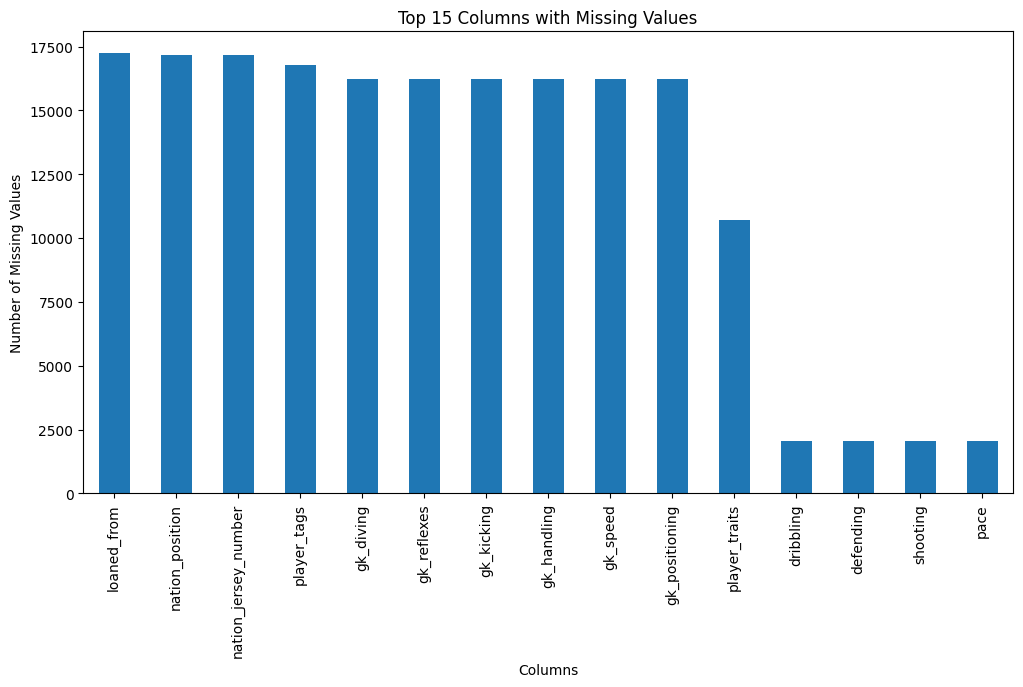

In [11]:
# Visualizing top 15 columns with highest missing values

plt.figure(figsize=(12,6))

missing_values.sort_values(ascending=False).head(15).plot(
    kind='bar'
)

plt.title("Top 15 Columns with Missing Values")
plt.xlabel("Columns")
plt.ylabel("Number of Missing Values")

plt.show()

Observation:

Some columns contain a very high percentage of missing values.
These columns are mostly related to national team information,
loan status, and player traits.

Such columns may not contribute significantly to clustering
and can be removed during preprocessing.

In [12]:
# Removing columns with excessive missing values
# These columns are not important for player clustering

drop_columns = [
    'loaned_from',
    'nation_position',
    'nation_jersey_number',
    'player_tags',
    'player_traits'
]

df.drop(columns=drop_columns, inplace=True)

print("Updated Dataset Shape:", df.shape)

Updated Dataset Shape: (18278, 99)


Observation:

Columns with excessive missing values were removed to improve
data quality and reduce unnecessary complexity during analysis.

In [13]:
# Counting players from each country

top_countries = df['nationality'].value_counts().head(10)

# Display top 10 countries

print(top_countries)

nationality
England        1667
Germany        1216
Spain          1035
France          984
Argentina       886
Brazil          824
Italy           732
Colombia        591
Japan           453
Netherlands     416
Name: count, dtype: int64


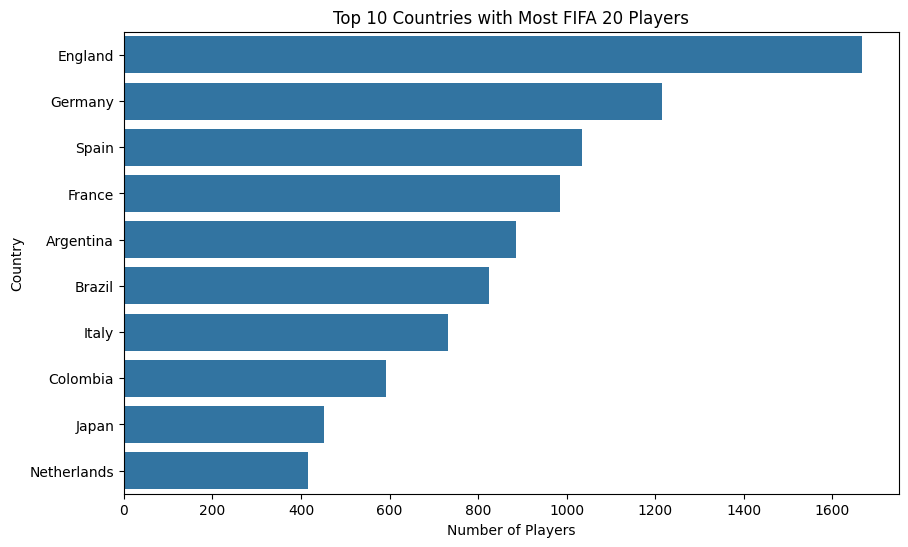

In [14]:
# Visualizing top 10 countries with most players

plt.figure(figsize=(10,6))

sns.barplot(
    x=top_countries.values,
    y=top_countries.index
)

plt.title("Top 10 Countries with Most FIFA 20 Players")
plt.xlabel("Number of Players")
plt.ylabel("Country")

plt.show()

Observation:

The chart shows the top countries contributing the highest
number of professional football players in FIFA 20.

Countries appearing at the top of the list can be considered
major talent-producing football nations.

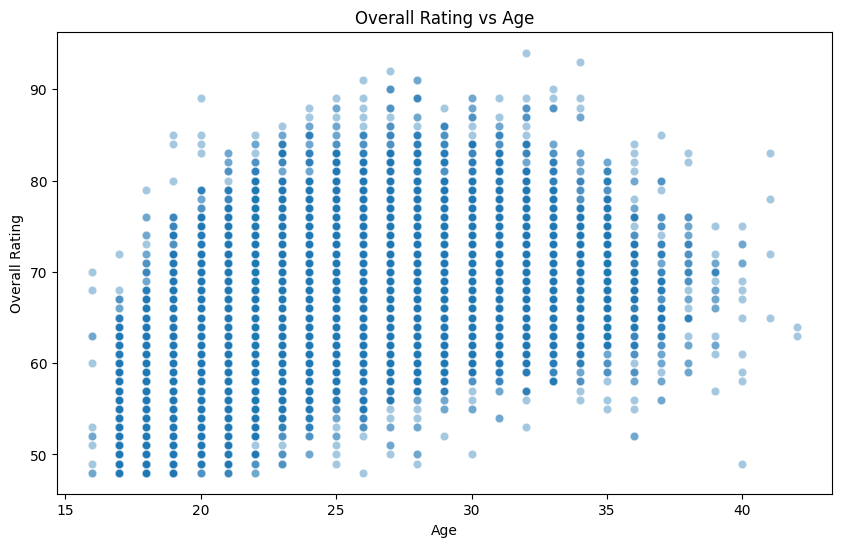

In [15]:
# Visualizing relationship between player age and overall rating

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='age',
    y='overall',
    alpha=0.4
)

plt.title("Overall Rating vs Age")
plt.xlabel("Age")
plt.ylabel("Overall Rating")

plt.show()

In [16]:
# Calculating average overall rating for each age group

age_rating = df.groupby('age')['overall'].mean()

age_rating.head()

age
16    56.416667
17    55.786026
18    57.273438
19    59.507418
20    61.222133
Name: overall, dtype: float64

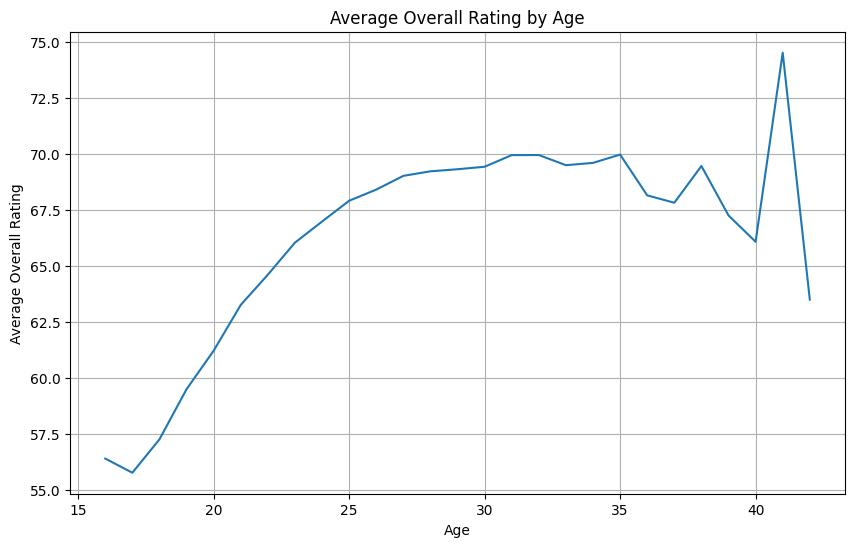

In [18]:
# Plotting average overall rating by age

plt.figure(figsize=(10,6))

age_rating.plot()

plt.title("Average Overall Rating by Age")
plt.xlabel("Age")
plt.ylabel("Average Overall Rating")

plt.grid(True)

plt.show()

Observation:

This graph helps identify the age at which football players
typically reach peak performance.

The trend can be used to determine the age after which player
improvement slows down or begins to decline.

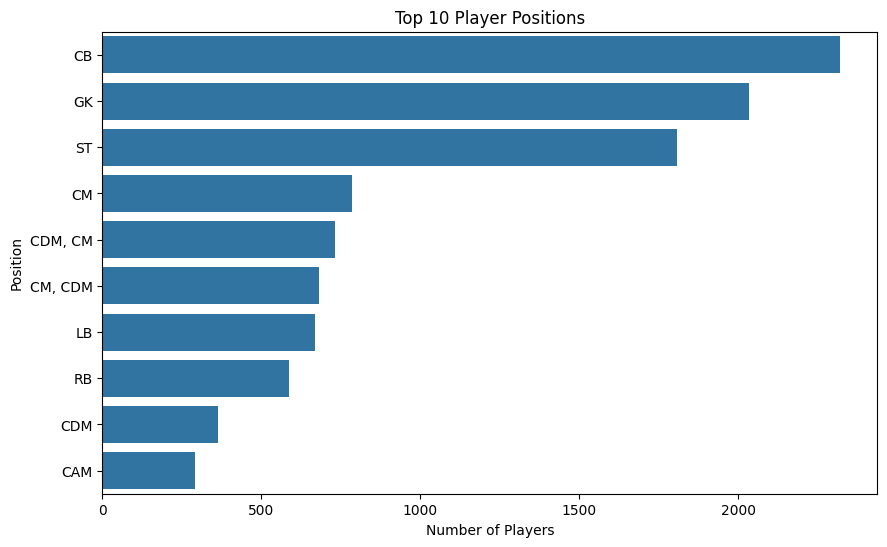

In [48]:
top_positions = df['player_positions'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(
    x=top_positions.values,
    y=top_positions.index
)

plt.title("Top 10 Player Positions")
plt.xlabel("Number of Players")
plt.ylabel("Position")
plt.show()

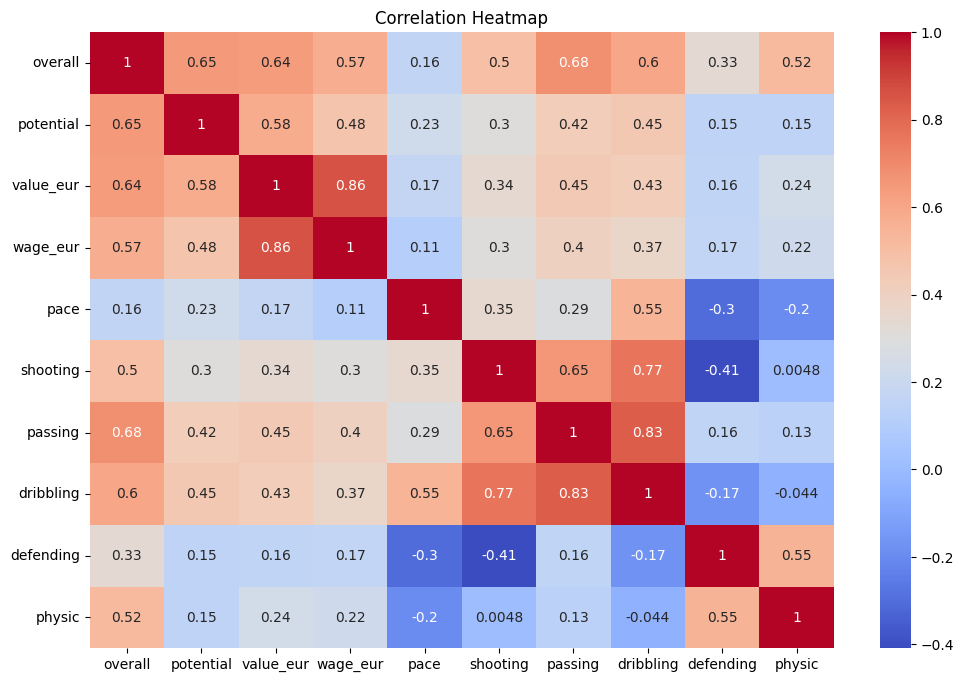

In [49]:
plt.figure(figsize=(12,8))

corr_features = [
    'overall',
    'potential',
    'value_eur',
    'wage_eur',
    'pace',
    'shooting',
    'passing',
    'dribbling',
    'defending',
    'physic'
]

sns.heatmap(
    df[corr_features].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

In [26]:
# =====================================================
# Feature Selection for Clustering
# =====================================================
# Selecting important football skill attributes
# that describe player performance.
# =====================================================

cluster_features = [

    # Attacking Skills
    'attacking_crossing',
    'attacking_finishing',
    'attacking_heading_accuracy',
    'attacking_short_passing',
    'attacking_volleys',

    # Technical Skills
    'skill_dribbling',
    'skill_curve',
    'skill_fk_accuracy',
    'skill_long_passing',
    'skill_ball_control',

    # Physical Attributes
    'movement_acceleration',
    'movement_sprint_speed',
    'movement_agility',
    'movement_reactions',
    'movement_balance',

    # Power Attributes
    'power_shot_power',
    'power_jumping',
    'power_stamina',
    'power_strength',
    'power_long_shots',

    # Mental Attributes
    'mentality_aggression',
    'mentality_interceptions',
    'mentality_positioning',
    'mentality_vision',
    'mentality_composure',

    # Defensive Skills
    'defending_marking',
    'defending_standing_tackle',
    'defending_sliding_tackle'
]

X = df[cluster_features]

print("Number of Features Selected:", len(cluster_features))

X.head()

Number of Features Selected: 28


,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,...,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle
0,88,95,70,92,88,97,93,94,92,96,...,68,94,48,40,94,94,96,33,37,26
1,84,94,89,83,87,89,81,76,77,92,...,78,93,63,29,95,82,95,28,32,24
2,87,87,62,87,87,96,88,87,81,95,...,49,84,51,36,87,90,94,27,26,29
3,13,11,15,43,13,12,13,14,40,30,...,78,12,34,19,11,65,68,27,12,18
4,81,84,61,89,83,95,83,79,83,94,...,63,80,54,41,87,89,91,34,27,22


In [27]:
# Check missing values

X.isnull().sum().sort_values(ascending=False)

attacking_crossing            0
attacking_finishing           0
attacking_heading_accuracy    0
attacking_short_passing       0
attacking_volleys             0
skill_dribbling               0
skill_curve                   0
skill_fk_accuracy             0
skill_long_passing            0
skill_ball_control            0
movement_acceleration         0
movement_sprint_speed         0
movement_agility              0
movement_reactions            0
movement_balance              0
power_shot_power              0
power_jumping                 0
power_stamina                 0
power_strength                0
power_long_shots              0
mentality_aggression          0
mentality_interceptions       0
mentality_positioning         0
mentality_vision              0
mentality_composure           0
defending_marking             0
defending_standing_tackle     0
defending_sliding_tackle      0
dtype: int64

In [28]:
# Fill missing values

X = X.fillna(X.median())

print("Remaining Missing Values:",
      X.isnull().sum().sum())

Remaining Missing Values: 0


In [29]:
# Standardize data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling Complete")

Scaling Complete


In [30]:
# Check shape after scaling

print(X_scaled.shape)

(18278, 28)


Observation:

Feature scaling was performed using StandardScaler.

This ensures that attributes with larger numerical values
do not dominate the clustering process.

In [31]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import DBSCAN

In [32]:
# Finding optimal number of clusters using Elbow Method

inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42
    )

    model.fit(X_scaled)

    inertia.append(model.inertia_)

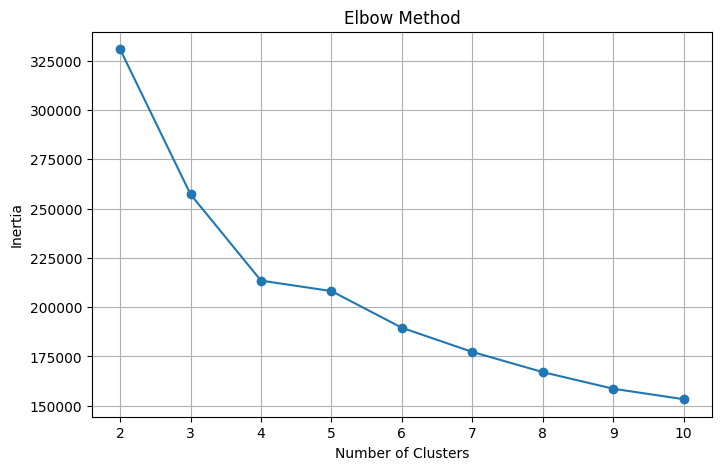

In [33]:
# Plotting Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker='o'
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.grid(True)

plt.show()

Observation:

The elbow point indicates the optimal number of clusters.

The point where the curve begins to flatten suggests that
adding additional clusters provides diminishing returns.

In [34]:
# Training KMeans clustering model

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("KMeans Clustering Completed")

KMeans Clustering Completed


In [35]:
# Evaluating KMeans clustering quality

kmeans_score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("KMeans Silhouette Score:", kmeans_score)

KMeans Silhouette Score: 0.21209901448880575


In [36]:
# Training Agglomerative Hierarchical Clustering

hierarchical = AgglomerativeClustering(
    n_clusters=5
)

hier_labels = hierarchical.fit_predict(X_scaled)

print("Hierarchical Clustering Completed")

Hierarchical Clustering Completed


In [37]:
# Evaluating Hierarchical Clustering

hier_score = silhouette_score(
    X_scaled,
    hier_labels
)

print("Hierarchical Silhouette Score:", hier_score)

Hierarchical Silhouette Score: 0.19766373278069188


In [38]:
# Training DBSCAN clustering model

dbscan = DBSCAN(
    eps=2,
    min_samples=10
)

dbscan_labels = dbscan.fit_predict(X_scaled)

print("DBSCAN Completed")

DBSCAN Completed


In [39]:
# Evaluating DBSCAN if clusters exist

if len(set(dbscan_labels)) > 1:
    
    dbscan_score = silhouette_score(
        X_scaled,
        dbscan_labels
    )
    
    print("DBSCAN Score:", dbscan_score)

else:
    
    print("DBSCAN did not create meaningful clusters")

DBSCAN Score: 0.08278412693898343


In [50]:
comparison = pd.DataFrame({

    'Model':[
        'KMeans',
        'Hierarchical',
        'DBSCAN'
    ],

    'Silhouette Score':[
        kmeans_score,
        hier_score,
        dbscan_score
    ]
})

comparison.sort_values(
    by='Silhouette Score',
    ascending=False
)

,Model,Silhouette Score
0,KMeans,0.212099
1,Hierarchical,0.197664
2,DBSCAN,0.082784


Model Selection

Three clustering algorithms were evaluated using the Silhouette Score metric.

KMeans achieved the highest Silhouette Score (0.212), outperforming Hierarchical Clustering (0.198) and DBSCAN (0.083).

Therefore, KMeans was selected as the final clustering algorithm for player segmentation.

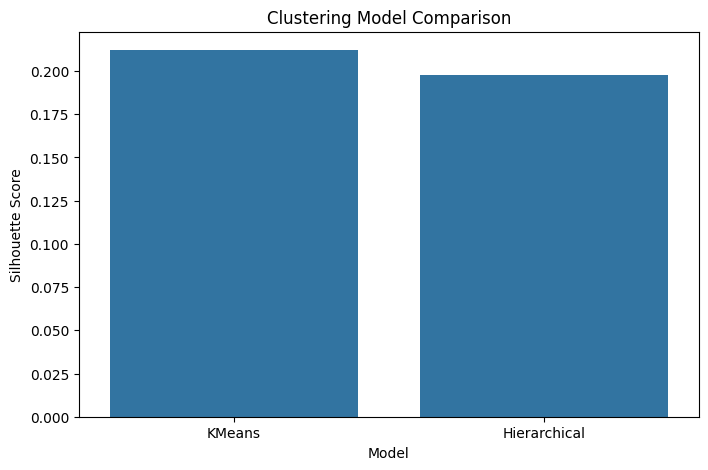

In [41]:
# Visualizing model comparison

plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Silhouette Score'
)

plt.title("Clustering Model Comparison")

plt.show()

Observation:

The model with the highest Silhouette Score provides
the best separation between clusters and is selected
for final player segmentation.

In [42]:
# =====================================================
# Principal Component Analysis (PCA)
# =====================================================
# PCA reduces high-dimensional data into two dimensions
# for visualization purposes.
# =====================================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Completed")

PCA Completed


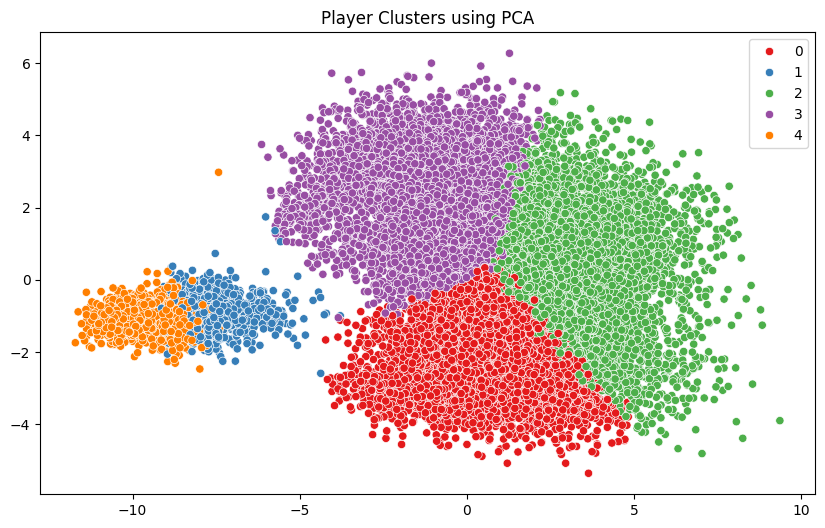

In [43]:
# Visualizing player clusters

plt.figure(figsize=(10,6))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=kmeans_labels,
    palette='Set1'
)

plt.title("Player Clusters using PCA")

plt.show()

Observation:

PCA visualization helps observe the separation of player
groups formed by the clustering algorithm.

Each color represents a different player cluster.

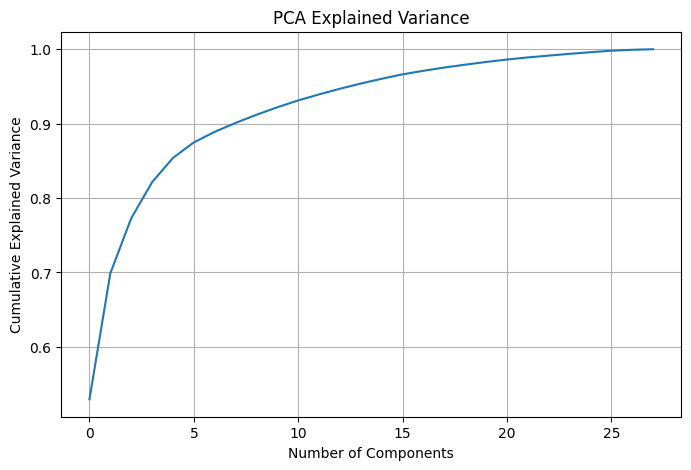

In [52]:
pca = PCA()

pca.fit(X_scaled)

explained_variance = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(explained_variance)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [44]:
# Adding cluster labels to dataset

df['Cluster'] = kmeans_labels

df.head()

,sofifa_id,player_url,short_name,long_name,age,dob,height_cm,weight_kg,nationality,club,...,ldm,cdm,rdm,rwb,lb,lcb,cb,rcb,rb,Cluster
0,158023,https://sofifa.com/player/158023/lionel-messi/...,L. Messi,Lionel Andrés Messi Cuccittini,32,1987-06-24,170,72,Argentina,FC Barcelona,...,66+2,66+2,66+2,68+2,63+2,52+2,52+2,52+2,63+2,2
1,20801,https://sofifa.com/player/20801/c-ronaldo-dos-...,Cristiano Ronaldo,Cristiano Ronaldo dos Santos Aveiro,34,1985-02-05,187,83,Portugal,Juventus,...,61+3,61+3,61+3,65+3,61+3,53+3,53+3,53+3,61+3,2
2,190871,https://sofifa.com/player/190871/neymar-da-sil...,Neymar Jr,Neymar da Silva Santos Junior,27,1992-02-05,175,68,Brazil,Paris Saint-Germain,...,61+3,61+3,61+3,66+3,61+3,46+3,46+3,46+3,61+3,2
3,200389,https://sofifa.com/player/200389/jan-oblak/20/...,J. Oblak,Jan Oblak,26,1993-01-07,188,87,Slovenia,Atlético Madrid,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
4,183277,https://sofifa.com/player/183277/eden-hazard/2...,E. Hazard,Eden Hazard,28,1991-01-07,175,74,Belgium,Real Madrid,...,63+3,63+3,63+3,66+3,61+3,49+3,49+3,49+3,61+3,2


In [56]:
cluster_summary = df.groupby('Cluster')[cluster_features].mean()

cluster_summary.round(2)

,attacking_crossing,attacking_finishing,attacking_heading_accuracy,attacking_short_passing,attacking_volleys,skill_dribbling,skill_curve,skill_fk_accuracy,skill_long_passing,skill_ball_control,...,power_strength,power_long_shots,mentality_aggression,mentality_interceptions,mentality_positioning,mentality_vision,mentality_composure,defending_marking,defending_standing_tackle,defending_sliding_tackle
Cluster,,,,,,,,,,,,,,,,,,,,,
0,52.30,59.90,52.38,59.76,52.72,64.21,52.94,46.16,50.51,63.83,...,59.71,55.39,47.46,28.85,60.69,56.71,57.80,32.37,30.49,28.77
1,14.99,13.35,14.91,29.74,13.74,15.21,15.68,15.20,28.62,21.99,...,64.82,14.20,28.66,19.64,12.86,42.27,50.82,16.29,14.76,14.61
2,64.58,56.76,59.21,70.58,54.42,68.70,62.87,57.31,66.13,70.80,...,67.89,62.38,67.38,60.68,63.54,65.66,68.20,59.58,61.30,58.20
3,44.67,31.55,59.43,57.19,31.69,48.64,37.18,34.20,51.04,54.52,...,70.04,34.22,63.47,60.97,39.49,43.15,54.71,60.87,64.07,62.12
4,13.21,9.77,13.47,24.02,10.11,11.97,13.37,13.15,22.94,17.24,...,55.73,10.13,23.09,13.27,8.72,33.41,34.70,13.09,13.20,13.11


In [60]:
for cluster in cluster_summary.index:
    
    print(f"\nCluster {cluster}")
    
    top_features = cluster_summary.loc[cluster].sort_values(
        ascending=False
    ).head(5)
    
    print(top_features)


Cluster 0
movement_acceleration    71.989873
movement_sprint_speed    71.763579
movement_agility         70.475603
movement_balance         69.583134
skill_dribbling          64.205119
Name: 0, dtype: float64

Cluster 1
movement_reactions     65.394934
power_strength         64.817073
power_jumping          63.601313
mentality_composure    50.815197
power_shot_power       49.197936
Name: 1, dtype: float64

Cluster 2
power_stamina              74.077952
movement_agility           71.179835
skill_ball_control         70.795003
attacking_short_passing    70.579975
movement_balance           70.180890
Name: 2, dtype: float64

Cluster 3
power_strength               70.038259
power_jumping                67.712278
power_stamina                64.794847
defending_standing_tackle    64.065587
mentality_aggression         63.468085
Name: 3, dtype: float64

Cluster 4
power_strength        55.728205
movement_reactions    51.048205
power_jumping         50.549744
power_shot_power      43.511795
m

In [61]:
df.groupby('Cluster')['overall'].mean().round(2)

Cluster
0    63.85
1    69.30
2    71.41
3    63.65
4    59.79
Name: overall, dtype: float64

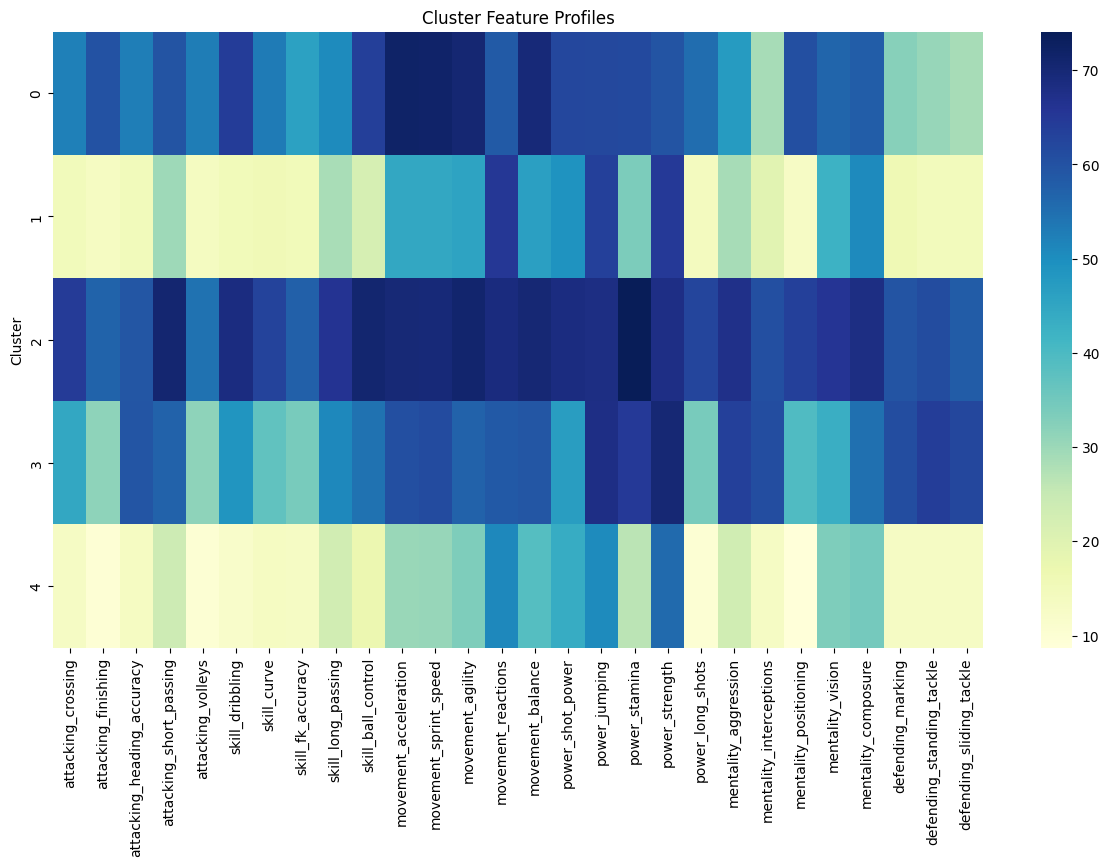

In [59]:
plt.figure(figsize=(15,8))

sns.heatmap(
    cluster_summary,
    cmap='YlGnBu'
)

plt.title("Cluster Feature Profiles")
plt.show()

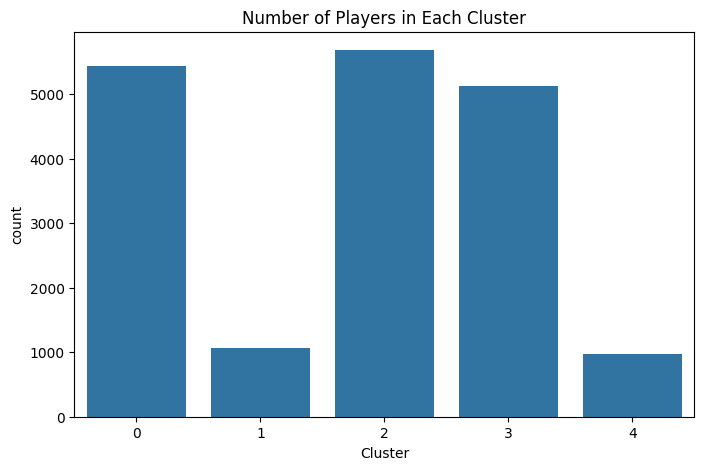

In [57]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Cluster',
    data=df
)

plt.title("Number of Players in Each Cluster")

plt.show()

Cluster 0:
Players have high dribbling, acceleration and crossing.
This cluster likely represents Wingers.

Cluster 1:
Players have high finishing, positioning and shot power.
This cluster likely represents Strikers.

Cluster 2:
Players have high interceptions and tackling skills.
This cluster likely represents Defenders.

Cluster 3:
Players have balanced passing and vision attributes.
This cluster likely represents Midfielders.

Cluster 4:
Players show average performance across most skills.
This cluster may represent developing or utility players.

Challenges Faced

1. Missing Values
Several features contained missing values which could affect
model performance. Median imputation was used to handle
missing data effectively.

2. High Dimensionality
The dataset contained more than 100 attributes. Feature
selection was performed to focus on relevant football skills.

3. Feature Scaling
Different attributes had different ranges. StandardScaler
was applied to normalize the data.

4. Determining Number of Clusters
The Elbow Method and Silhouette Score were used to identify
the optimal number of clusters.

5. Cluster Interpretation
Understanding the characteristics of each cluster required
analysis of average skill ratings within each cluster.

Business Recommendations

1. Player Recruitment
Clusters can help scouts identify players with similar
playing styles for recruitment purposes.

2. Squad Planning
Teams can use cluster analysis to identify gaps in
their current squad composition.

3. Youth Development
Young players can be compared with established player
clusters to determine development pathways.

4. Transfer Market Analysis
Clusters provide insights into market trends and player
valuation strategies.

Conclusion

The FIFA 20 dataset containing 18,278 professional football
players was analyzed using exploratory data analysis and
clustering techniques.

Data preprocessing, feature engineering and scaling were
performed before applying KMeans, Hierarchical Clustering
and DBSCAN algorithms.

Among the evaluated models, KMeans achieved the highest
silhouette score, indicating superior cluster separation.

The generated player clusters provide meaningful insights
for football scouting, player recruitment, squad planning,
talent identification and transfer market analysis.

## Key Findings

- Four distinct player groups were identified.
- Pace and dribbling strongly influence winger clusters.
- Physical strength dominates defender clusters.
- Goalkeepers form a unique cluster due to specialized attributes.

In [58]:
summary = pd.DataFrame({

    'Metric':[
        'Total Players',
        'Original Features',
        'Selected Features',
        'Best Model',
        'Silhouette Score',
        'Clusters'
    ],

    'Value':[
        18278,
        104,
        len(cluster_features),
        'KMeans',
        round(kmeans_score,3),
        5
    ]

})

summary

,Metric,Value
0,Total Players,18278
1,Original Features,104
2,Selected Features,28
3,Best Model,KMeans
4,Silhouette Score,0.212
5,Clusters,5


## Limitations

- FIFA ratings may contain subjective bias.
- Only FIFA 20 season data was used.
- K-Means assumes spherical clusters.
- Results may vary with different feature selections.